# E-Commerce Data Analysis: Customer, Sales & Revenue Insights

## Project Overview

This project analyzes the Brazilian E-Commerce Public Dataset by Olist to identify sales trends, customer behavior, product performance, regional patterns, and actionable business insights.

### Objectives

- Analyze overall sales and profit performance

- Identify the best-performing product categories

- Compare regional performance

- Analyze customer segments

- Evaluate payment methods

- Examine order-status performance

- Generate actionable business recommendations

### Tools & Technologies

- Python

- Pandas

- NumPy

- Matplotlib

- Google Colab

### Key Business Questions

1. Which product categories generate the highest sales and profit?

2. Which customer segment contributes the most revenue?

3. Which regions perform best?

4. Which payment methods are most commonly used?

5. How do order statuses affect sales and profitability?



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
from google.colab import files
import pandas as pd

# Upload the CSV file directly into Colab
uploaded = files.upload()

# Get the uploaded filename automatically
filename = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(filename)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Saving ecommerce_sales_analysis_dataset (1).csv to ecommerce_sales_analysis_dataset (1) (1).csv
Dataset loaded successfully!
Rows: 5000
Columns: 18


In [5]:
# Display the first 5 rows of the dataset

df.head()

,Order_Date,Order_ID,Customer_ID,Product_Name,Category,Region,City,Customer_Segment,Quantity,Unit_Price,Discount_Percent,Sales,Shipping_Cost,Profit,Payment_Method,Order_Status,Customer_Age,Review_Rating
0,2024-01-01,ORD00387,CUST2458,Coffee Maker,Home & Kitchen,Central,Lucknow,Consumer,3,86.35,0,259.04,23.14,33.49,UPI,Completed,56,2.9
1,2024-01-01,ORD00274,CUST3103,Jeans,Fashion,East,Guwahati,Consumer,4,43.80,20,175.20,36.62,-33.93,Credit Card,Completed,42,2.9
2,2024-01-01,ORD02118,CUST1776,Smartphone,Electronics,East,Bhubaneswar,Corporate,3,208.98,15,626.94,25.34,54.68,Cash on Delivery,Completed,38,3.9
3,2024-01-01,ORD00941,CUST1166,Laptop,Electronics,Central,Bhopal,Consumer,2,957.36,5,1914.72,13.05,103.43,Cash on Delivery,Completed,52,3.7
4,2024-01-01,ORD03747,CUST1591,Shampoo,Beauty,Central,Bhopal,Consumer,3,159.49,5,478.46,29.79,79.15,PayPal,Completed,32,3.3


In [6]:
# Check dataset structure and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_Date        5000 non-null   object 
 1   Order_ID          5000 non-null   object 
 2   Customer_ID       5000 non-null   object 
 3   Product_Name      5000 non-null   object 
 4   Category          5000 non-null   object 
 5   Region            5000 non-null   object 
 6   City              5000 non-null   object 
 7   Customer_Segment  5000 non-null   object 
 8   Quantity          5000 non-null   int64  
 9   Unit_Price        5000 non-null   float64
 10  Discount_Percent  5000 non-null   int64  
 11  Sales             5000 non-null   float64
 12  Shipping_Cost     5000 non-null   float64
 13  Profit            5000 non-null   float64
 14  Payment_Method    5000 non-null   object 
 15  Order_Status      5000 non-null   object 
 16  Customer_Age      5000 non-null   int64  


In [7]:
# Check for missing values and duplicate rows

print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values in each column:
Order_Date          0
Order_ID            0
Customer_ID         0
Product_Name        0
Category            0
Region              0
City                0
Customer_Segment    0
Quantity            0
Unit_Price          0
Discount_Percent    0
Sales               0
Shipping_Cost       0
Profit              0
Payment_Method      0
Order_Status        0
Customer_Age        0
Review_Rating       0
dtype: int64

Total missing values: 0

Total duplicate rows: 0


In [8]:
# Statistical summary of numerical columns

df.describe()

,Quantity,Unit_Price,Discount_Percent,Sales,Shipping_Cost,Profit,Customer_Age,Review_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.969400,314.146198,8.503000,934.748492,27.810328,59.793946,40.973800,3.965940
std,1.420024,310.687853,5.860107,1111.769413,10.762554,153.830772,13.672575,0.722912
min,1.000000,10.600000,0.000000,12.830000,4.200000,-421.650000,18.000000,1.200000
25%,2.000000,115.822500,5.000000,250.347500,19.447500,-15.985000,29.000000,3.500000
50%,3.000000,208.685000,10.000000,554.415000,27.920000,13.165000,41.000000,4.000000
75%,4.000000,371.082500,15.000000,1137.255000,35.730000,79.950000,53.000000,4.600000
max,5.000000,1399.810000,20.000000,6929.060000,57.140000,1680.970000,64.000000,5.000000


In [9]:
# Analyze categorical columns

categorical_columns = [
    'Category',
    'Region',
    'City',
    'Customer_Segment',
    'Payment_Method',
    'Order_Status'
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Category ---
Category
Electronics        1056
Fashion             921
Home & Kitchen      898
Office Supplies     803
Sports              714
Beauty              608
Name: count, dtype: int64

--- Region ---
Region
West       1063
South      1043
Central    1000
North       988
East        906
Name: count, dtype: int64

--- City ---
City
Ahmedabad      369
Hyderabad      363
Bhopal         354
Bengaluru      348
Pune           347
Mumbai         347
Delhi          335
Chennai        332
Indore         331
Jaipur         330
Chandigarh     323
Bhubaneswar    316
Lucknow        315
Guwahati       307
Kolkata        283
Name: count, dtype: int64

--- Customer_Segment ---
Customer_Segment
Consumer          2738
Corporate         1238
Small Business    1024
Name: count, dtype: int64

--- Payment_Method ---
Payment_Method
UPI                 1523
Credit Card         1240
Debit Card          1009
Cash on Delivery     631
PayPal               597
Name: count, dtype: int64

--- Order_Statu

In [10]:
# Sales performance by category

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

print("Total Sales by Category:")
print(category_sales)

Total Sales by Category:
Category
Electronics        2431313.79
Home & Kitchen      707568.17
Office Supplies     554985.51
Sports              398929.02
Fashion             372858.91
Beauty              208087.06
Name: Sales, dtype: float64


In [11]:
# Profit performance by category

category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

print("Total Profit by Category:")
print(category_profit)

Total Profit by Category:
Category
Electronics        197497.00
Home & Kitchen      40554.82
Office Supplies     29740.32
Sports              18685.20
Fashion              9346.69
Beauty               3145.70
Name: Profit, dtype: float64


In [12]:
# Sales performance by region

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print("Total Sales by Region:")
print(region_sales)

Total Sales by Region:
Region
West       1044859.27
South       978107.66
North       905592.67
Central     878655.88
East        866526.98
Name: Sales, dtype: float64


In [13]:
# Profit performance by region

region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

print("Total Profit by Region:")
print(region_profit)

Total Profit by Region:
Region
West       70541.36
South      59781.50
North      58501.67
East       56105.57
Central    54039.63
Name: Profit, dtype: float64


In [14]:
# Sales and profit performance by customer segment

segment_analysis = df.groupby('Customer_Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).sort_values('Sales', ascending=False)

segment_analysis.columns = ['Total Sales', 'Total Profit', 'Number of Orders']

print("Customer Segment Performance:")
print(segment_analysis)

Customer Segment Performance:
                  Total Sales  Total Profit  Number of Orders
Customer_Segment                                             
Consumer           2536577.72     162539.32              2738
Corporate          1164011.85      71625.20              1238
Small Business      973152.89      64805.21              1024


In [15]:
# Sales performance by payment method

payment_analysis = df.groupby('Payment_Method').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).sort_values('Sales', ascending=False)

payment_analysis.columns = ['Total Sales', 'Total Profit', 'Number of Orders']

print("Payment Method Performance:")
print(payment_analysis)

Payment Method Performance:
                  Total Sales  Total Profit  Number of Orders
Payment_Method                                               
UPI                1472799.35      99199.39              1523
Credit Card        1156542.60      69637.77              1240
Debit Card          889915.76      51424.56              1009
Cash on Delivery    604036.26      47044.52               631
PayPal              550448.49      31663.49               597


In [16]:
# Order status analysis

status_analysis = df.groupby('Order_Status').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).sort_values('Sales', ascending=False)

status_analysis.columns = ['Total Sales', 'Total Profit', 'Number of Orders']

print("Order Status Performance:")
print(status_analysis)

Order Status Performance:
              Total Sales  Total Profit  Number of Orders
Order_Status                                             
Completed      3745118.72     242237.07              3992
Returned        585995.65      36754.83               641
Cancelled       342628.09      19977.83               367


In [17]:
# Analyze the impact of discount on profit

discount_analysis = df.groupby('Discount_Percent').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order_ID': 'count'
}).sort_index()

discount_analysis.columns = ['Total Sales', 'Total Profit', 'Number of Orders']

print("Discount Impact Analysis:")
print(discount_analysis)

Discount Impact Analysis:
                  Total Sales  Total Profit  Number of Orders
Discount_Percent                                             
0                   895770.84     129863.01               942
5                  1214587.44     119491.47              1249
10                 1333049.65      63356.30              1504
15                  943083.56       -102.60               974
20                  287250.97     -13638.45               331


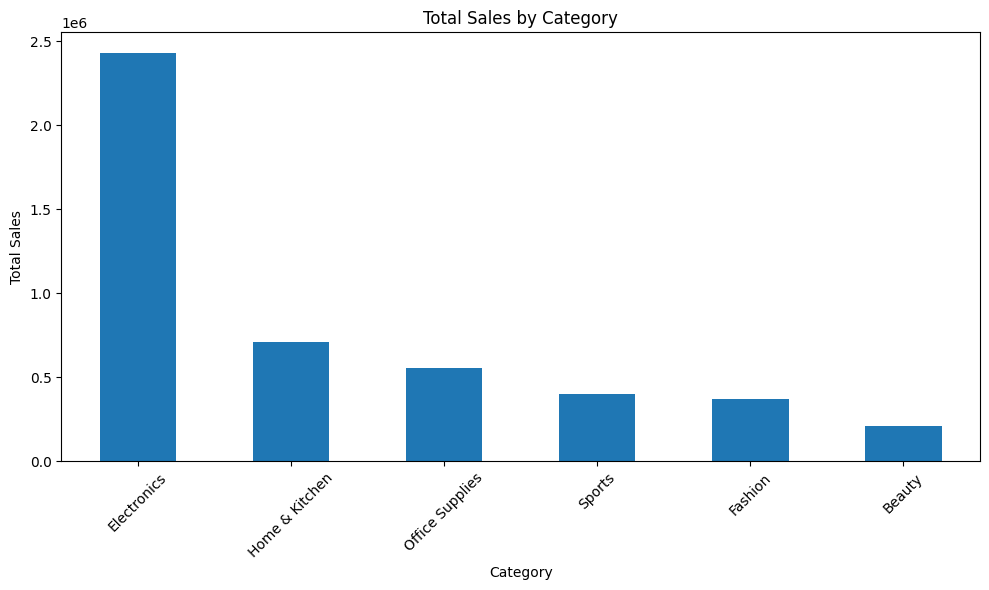

In [18]:
import matplotlib.pyplot as plt

# Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

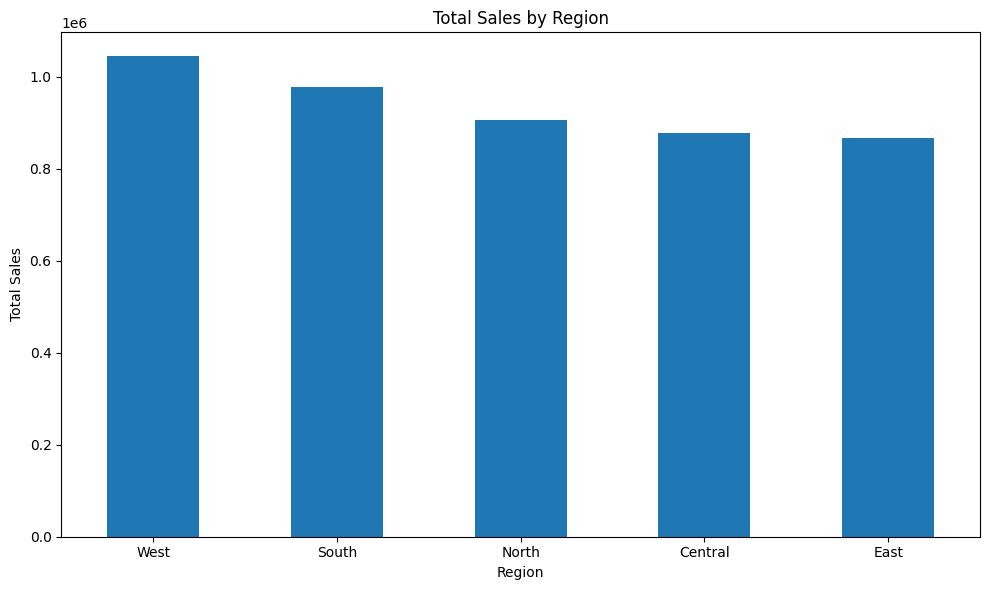

In [19]:
# Sales by Region

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
region_sales.plot(kind='bar')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

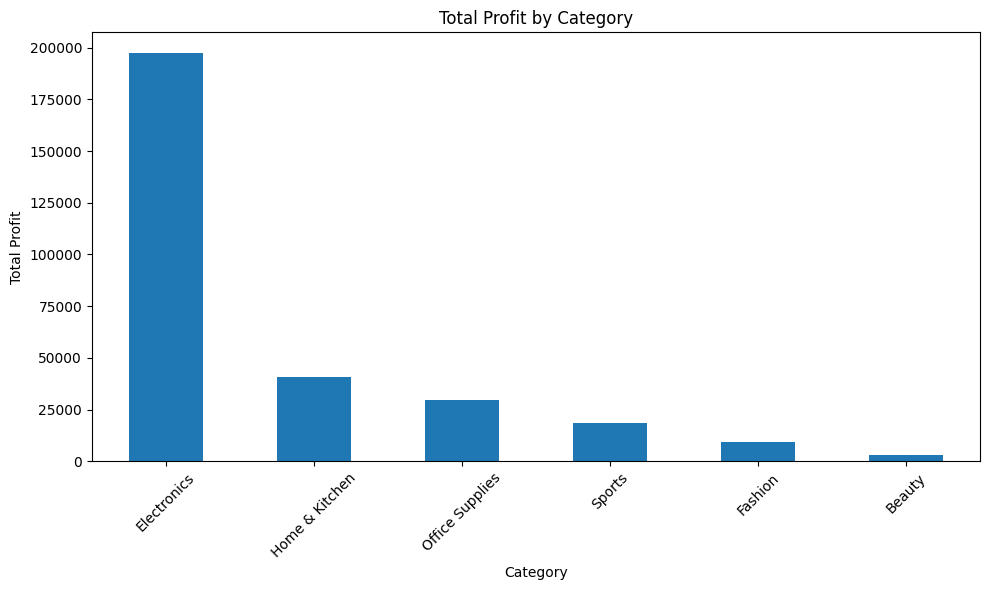

In [20]:
# Profit by Category

category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
category_profit.plot(kind='bar')

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

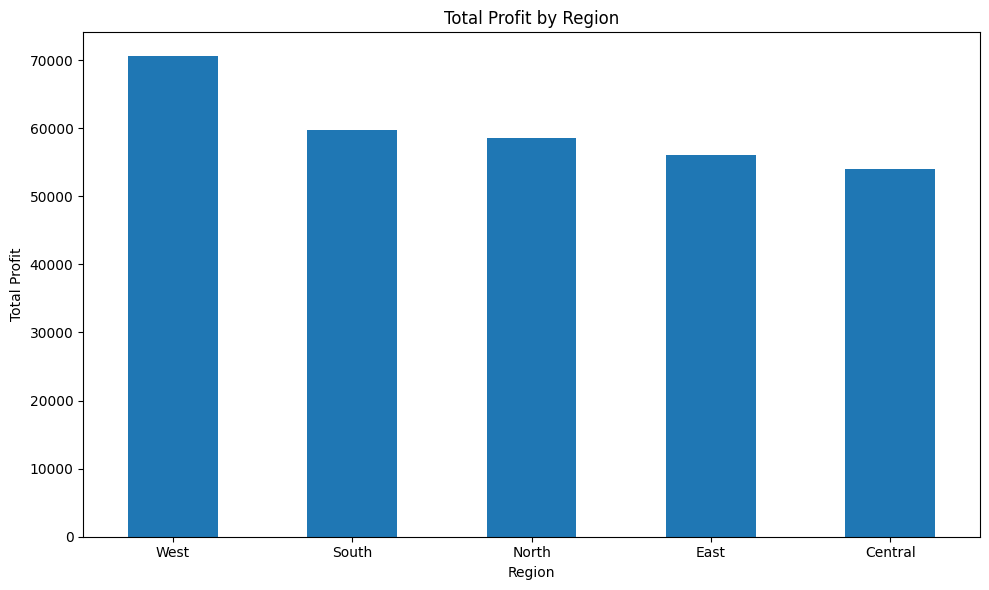

In [21]:
# Profit by Region

region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
region_profit.plot(kind='bar')

plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

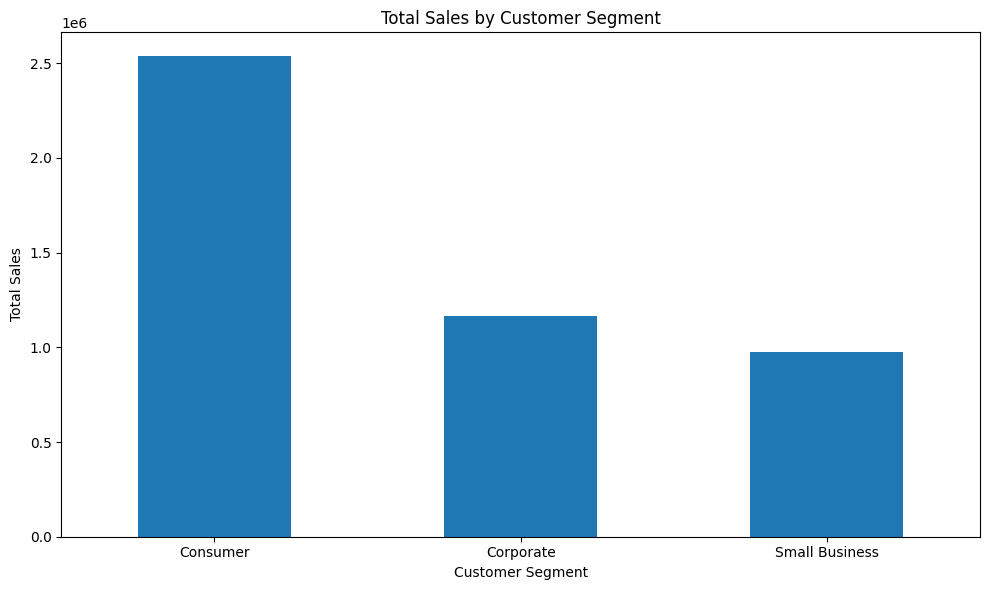

In [22]:
# Sales by Customer Segment

segment_sales = df.groupby('Customer_Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
segment_sales.plot(kind='bar')

plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

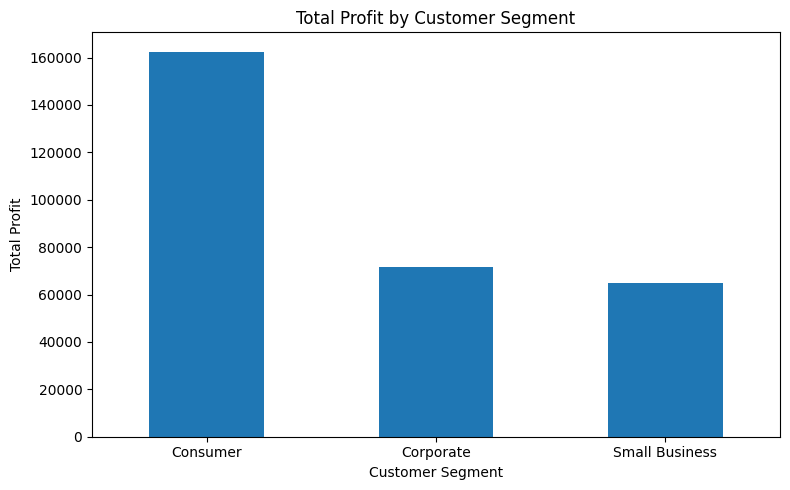

In [23]:
# Total Profit by Customer Segment

segment_profit = df.groupby('Customer_Segment')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
segment_profit.plot(kind='bar')

plt.title('Total Profit by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

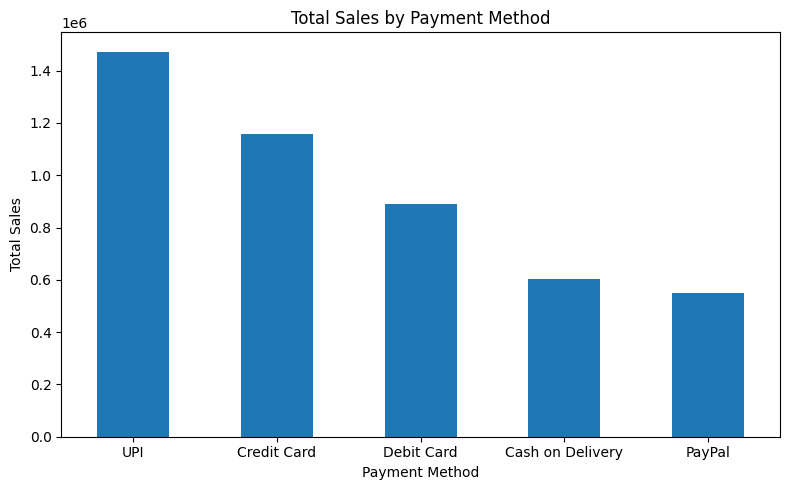

In [24]:
# Total Sales by Payment Method

payment_sales = df.groupby('Payment_Method')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
payment_sales.plot(kind='bar')

plt.title('Total Sales by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

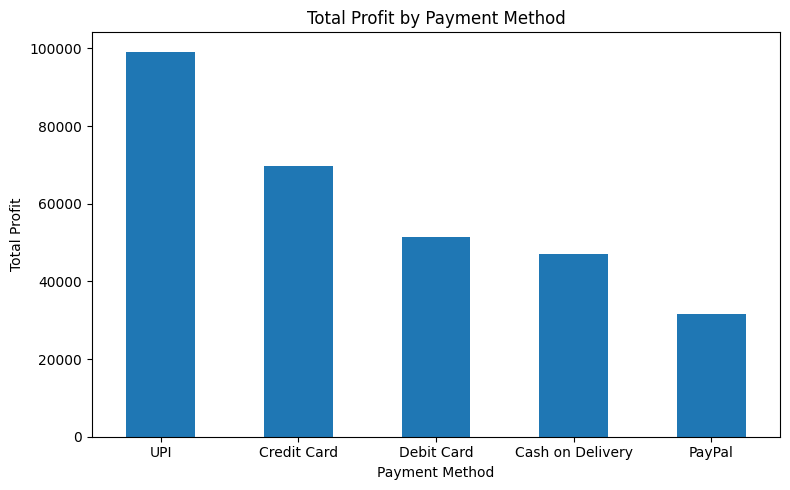

In [25]:
# Total Profit by Payment Method

payment_profit = df.groupby('Payment_Method')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
payment_profit.plot(kind='bar')

plt.title('Total Profit by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

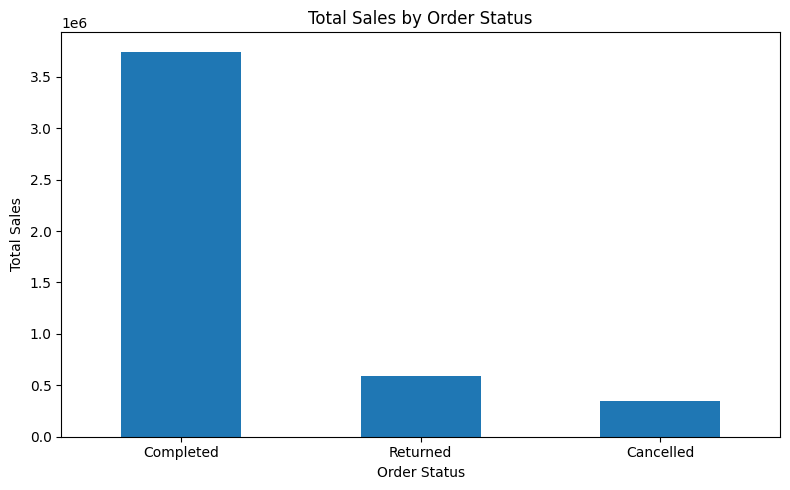

In [26]:
# Total Sales by Order Status

status_sales = df.groupby('Order_Status')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
status_sales.plot(kind='bar')

plt.title('Total Sales by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

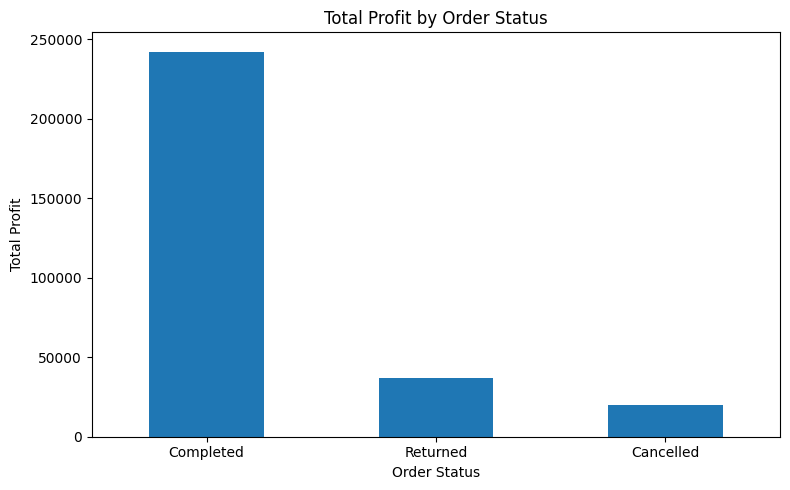

In [27]:
# Total Profit by Order Status

status_profit = df.groupby('Order_Status')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
status_profit.plot(kind='bar')

plt.title('Total Profit by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Business Insights & Recommendations

### Key Insights

1. Electronics is the strongest-performing product category in terms of both sales and profit.

2. The Consumer customer segment generates the highest overall sales and profit compared with Corporate and Home Office customers.

3. The regions show relatively similar profit performance, although one region contributes slightly higher profit than the others.

4. UPI and Credit Card are the leading payment methods by sales, while PayPal contributes comparatively lower sales and profit.

5. Completed orders contribute the majority of total sales and profit, while cancelled and other non-completed orders contribute significantly less.

6. The strong performance of Electronics indicates that the company should continue focusing on this category while identifying opportunities to improve weaker categories.

### Business Recommendations

- Increase inventory and marketing investment in high-performing Electronics products.
- Develop targeted marketing campaigns for the Consumer customer segment.
- Investigate why certain regions and product categories generate lower profits.
- Encourage customers to use high-performing digital payment methods.
- Analyze cancelled orders to identify reasons for order cancellation.
- Focus on improving profitability of lower-performing categories instead of relying only on high-sales categories.

## Conclusion

This e-commerce sales analysis provides a clear view of sales and profitability across product categories, regions, customer segments, payment methods, and order statuses.

The analysis shows that Electronics is the strongest-performing category, while the Consumer segment contributes the highest sales and profit. Digital payment methods such as UPI and Credit Card also represent important sales channels.

These insights can help businesses optimize inventory, target high-value customer segments, improve weaker categories, and reduce order cancellations.

Overall, this project demonstrates the use of Python, Pandas, Matplotlib, data aggregation, exploratory data analysis, and business-focused data interpretation to support data-driven decision making.